In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap

/Users/djibrildahoub/Documents/cours/2025_2026/s2/ThecCont/projet/Projet_Final_Djibril_Neil_Adem/amineEnv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('data/city_lifestyle_dataset.csv')

X = df.drop(['city_name', 'country'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Projeter les données en 2 dimensions

In [4]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

/Users/djibrildahoub/Documents/cours/2025_2026/s2/ThecCont/projet/Projet_Final_Djibril_Neil_Adem/amineEnv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Visualiser le résultat dans un graphique 2D

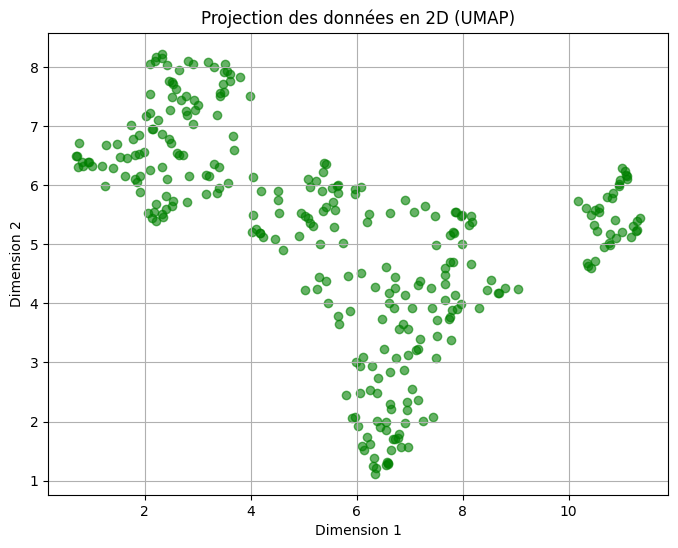

In [5]:
df_umap = pd.DataFrame(X_umap, columns=['Dim_1', 'Dim_2'])

plt.figure(figsize=(8, 6))
plt.scatter(df_umap['Dim_1'], df_umap['Dim_2'], alpha=0.6, c='green')
plt.title('Projection des données en 2D (UMAP)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.show()

### Analyse de la structure

Après réduction de dimension avec UMAP, on passe de 8 colonnes à 2. Contrairement à la PCA, l'algorithme se concentre sur la préservation des voisinages locaux plutôt que sur la variance globale.
En regardant le nuage de points, on remarque que les groupes (clusters) sont beaucoup plus denses, compacts et mieux séparés. Cela met bien en évidence plusieurs profils de villes très distincts.

### Exporter les données en 2 dimensions

In [6]:
df_umap.to_csv('outputs/umap_emb_2d.csv', index=False)